In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional for ACF
from statsmodels.graphics.tsaplots import plot_acf

# Load all day-wise price files
price_files = sorted(glob.glob("../../../data_capsule/ROUND_3/prices_round_3_day_*.csv"))
prices = pd.concat([pd.read_csv(f, sep=';') for f in price_files], ignore_index=True)

# Pick the product you want to analyze
product = "VELVETFRUIT_EXTRACT"   # change this to any product in prices["product"].unique()

df = prices.loc[prices["product"] == product].copy()
df = df.sort_values(["day", "timestamp"]).reset_index(drop=True)

# Best bid / ask from level 1
df["best_bid"] = df["bid_price_1"]
df["best_ask"] = df["ask_price_1"]

# Mid price, spread, and depth at best quotes
df["mid_calc"] = (df["best_bid"] + df["best_ask"]) / 2
df["spread"] = df["best_ask"] - df["best_bid"]
df["bid_depth"] = df["bid_volume_1"]
df["ask_depth"] = df["ask_volume_1"]

# Log mid-price and returns within each day (important: do not diff across day boundary)
df["log_mid"] = np.log(df["mid_calc"].replace(0, np.nan))
df["log_ret"] = df.groupby("day")["log_mid"].diff()

# Drop invalid rows for later use
rets = df["log_ret"].replace([np.inf, -np.inf], np.nan).dropna()

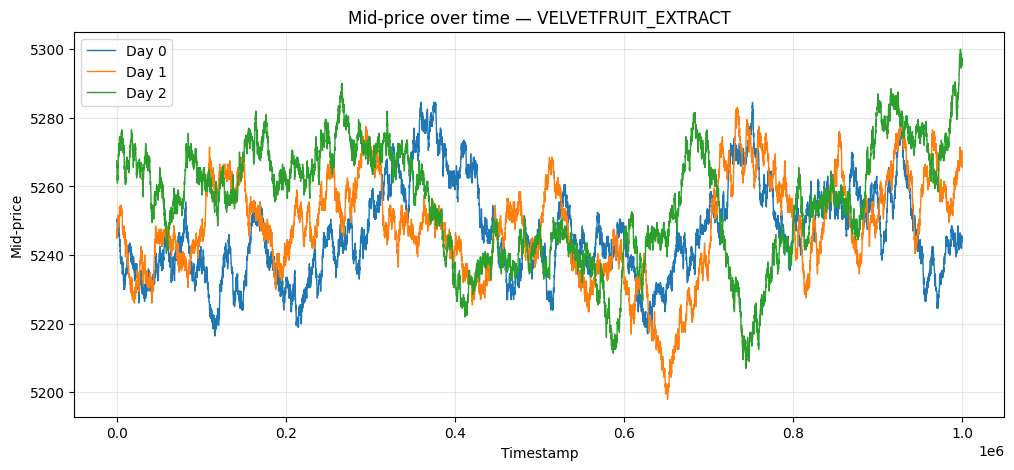

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

for day, g in df.groupby("day"):
    ax.plot(g["timestamp"], g["mid_calc"], label=f"Day {day}", linewidth=1)

ax.set_title(f"Mid-price over time — {product}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Mid-price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

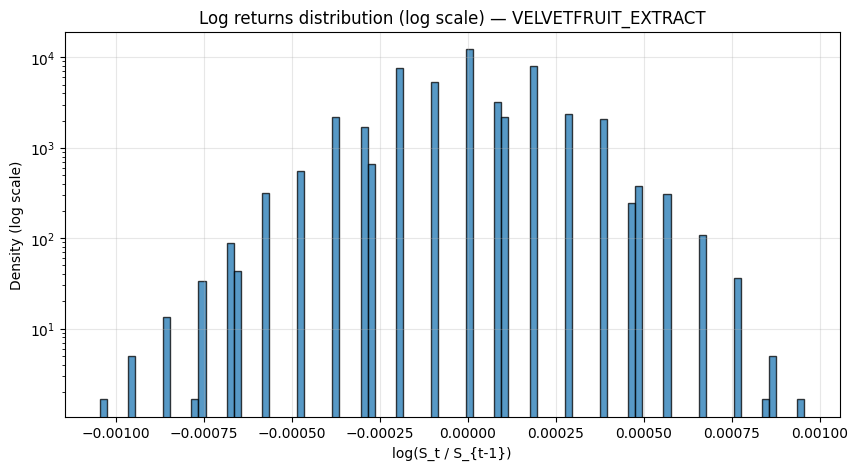

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rets, bins=100, density=True, alpha=0.75, edgecolor="black")
ax.set_yscale("log")

ax.set_title(f"Log returns distribution (log scale) — {product}")
ax.set_xlabel("log(S_t / S_{t-1})")
ax.set_ylabel("Density (log scale)")
ax.grid(True, alpha=0.3)
plt.show()

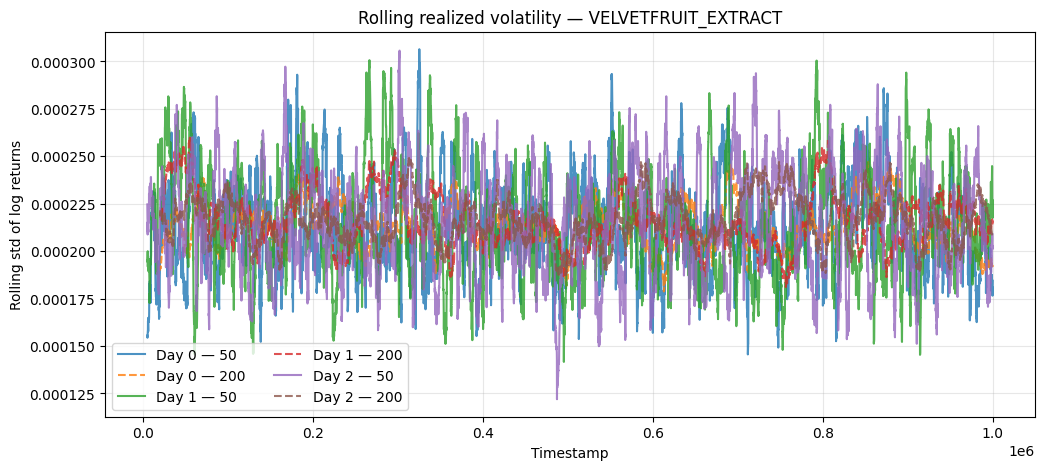

In [4]:
df["rv_50"] = df.groupby("day")["log_ret"].transform(lambda s: s.rolling(50).std())
df["rv_200"] = df.groupby("day")["log_ret"].transform(lambda s: s.rolling(200).std())

fig, ax = plt.subplots(figsize=(12, 5))

for day, g in df.groupby("day"):
    ax.plot(g["timestamp"], g["rv_50"], label=f"Day {day} — 50", alpha=0.8)
    ax.plot(g["timestamp"], g["rv_200"], label=f"Day {day} — 200", alpha=0.8, linestyle="--")

ax.set_title(f"Rolling realized volatility — {product}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling std of log returns")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.show()

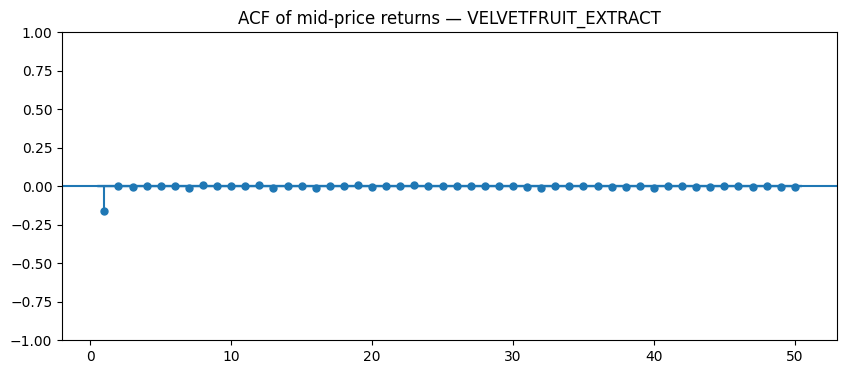

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(rets, lags=50, ax=ax, zero=False)
ax.set_title(f"ACF of mid-price returns — {product}")
plt.show()

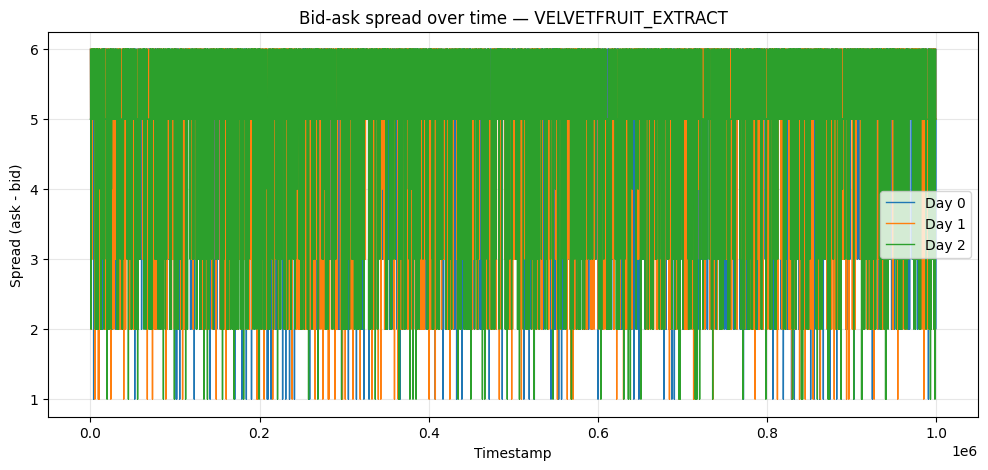

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for day, g in df.groupby("day"):
    ax.plot(g["timestamp"], g["spread"], label=f"Day {day}", linewidth=1)

ax.set_title(f"Bid-ask spread over time — {product}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Spread (ask - bid)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

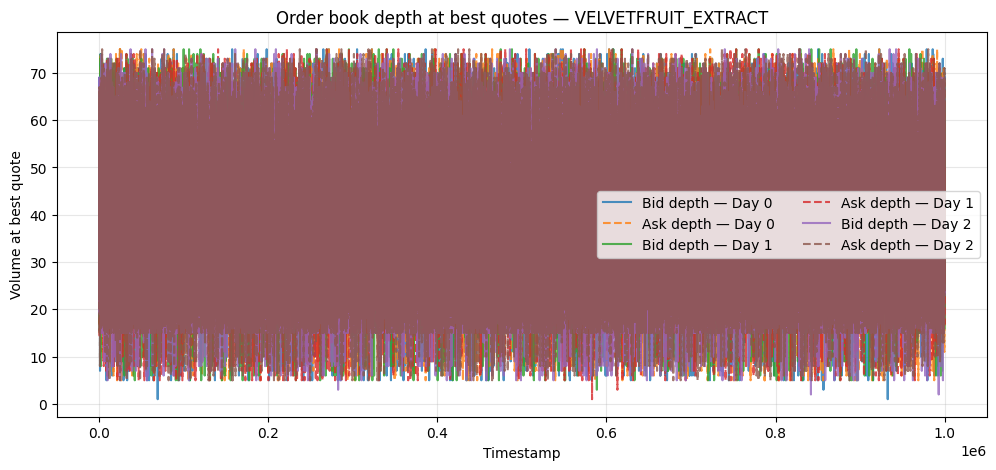

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

for day, g in df.groupby("day"):
    ax.plot(g["timestamp"], g["bid_depth"], label=f"Bid depth — Day {day}", alpha=0.8)
    ax.plot(g["timestamp"], g["ask_depth"], label=f"Ask depth — Day {day}", alpha=0.8, linestyle="--")

ax.set_title(f"Order book depth at best quotes — {product}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Volume at best quote")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.show()